# Phase 2


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/BikeRentalData.csv")

In [ ]:
df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,registered,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,13,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,32,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,27,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,10,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1


In [ ]:
df.shape

(17379, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   yr          17379 non-null  int64  
 2   mnth        17379 non-null  int64  
 3   hr          17379 non-null  int64  
 4   holiday     17379 non-null  int64  
 5   weekday     17379 non-null  int64  
 6   workingday  17379 non-null  int64  
 7   weathersit  17379 non-null  int64  
 8   temp        17379 non-null  float64
 9   atemp       17379 non-null  float64
 10  hum         17379 non-null  float64
 11  windspeed   17379 non-null  float64
 12  registered  17379 non-null  int64  
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(10)
memory usage: 1.9 MB


In [ ]:
df.describe()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,registered,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,153.786869,189.463088
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,151.357286,181.387599
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,34.000000,40.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,115.000000,142.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,220.000000,281.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,886.000000,977.000000


#Phase 3 - Data Cleaning and Preprocessing


Checking missing values

In [ ]:
df.isnull().sum()   # there is no null values in dataset

,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0


checking for duplicates

In [ ]:
df.duplicated().sum()  #not too many duplicates can simply drop them

np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

Encoding

The Weather forecast for the day
1: Clear, Few clouds, Partly cloudy, Partly cloudy
2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

 The current season (1:winter, 2:spring, 3:summer, 4:fall)
 weekday: day of the week

In [ ]:
df = pd.get_dummies(df, columns=['season', 'weathersit', 'weekday'], drop_first=True)

In [ ]:
df.head()

,yr,mnth,hr,holiday,workingday,temp,atemp,hum,windspeed,registered,...,season_4,weathersit_2,weathersit_3,weathersit_4,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,0,1,0,0,0,0.24,0.2879,0.81,0.0,13,...,False,False,False,False,False,False,False,False,False,True
1,0,1,1,0,0,0.22,0.2727,0.80,0.0,32,...,False,False,False,False,False,False,False,False,False,True
2,0,1,2,0,0,0.22,0.2727,0.80,0.0,27,...,False,False,False,False,False,False,False,False,False,True
3,0,1,3,0,0,0.24,0.2879,0.75,0.0,10,...,False,False,False,False,False,False,False,False,False,True
4,0,1,4,0,0,0.24,0.2879,0.75,0.0,1,...,False,False,False,False,False,False,False,False,False,True


Adding casual users col

casual: count of casual users

In [ ]:
df['casual'] = df['cnt'] - df['registered']

In [ ]:
df.head()

,yr,mnth,hr,holiday,workingday,temp,atemp,hum,windspeed,registered,...,weathersit_2,weathersit_3,weathersit_4,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,casual
0,0,1,0,0,0,0.24,0.2879,0.81,0.0,13,...,False,False,False,False,False,False,False,False,True,3
1,0,1,1,0,0,0.22,0.2727,0.80,0.0,32,...,False,False,False,False,False,False,False,False,True,8
2,0,1,2,0,0,0.22,0.2727,0.80,0.0,27,...,False,False,False,False,False,False,False,False,True,5
3,0,1,3,0,0,0.24,0.2879,0.75,0.0,10,...,False,False,False,False,False,False,False,False,True,3
4,0,1,4,0,0,0.24,0.2879,0.75,0.0,1,...,False,False,False,False,False,False,False,False,True,0


In [ ]:
(df['casual'] < 0).sum()

np.int64(0)

Checking outliers with help of boxplot

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


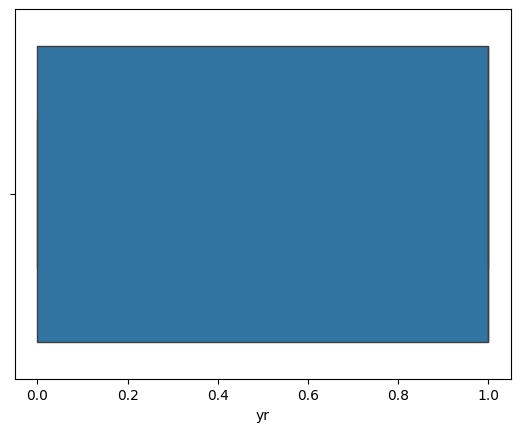

In [ ]:
sns.boxplot(x=df['yr'])
plt.show()

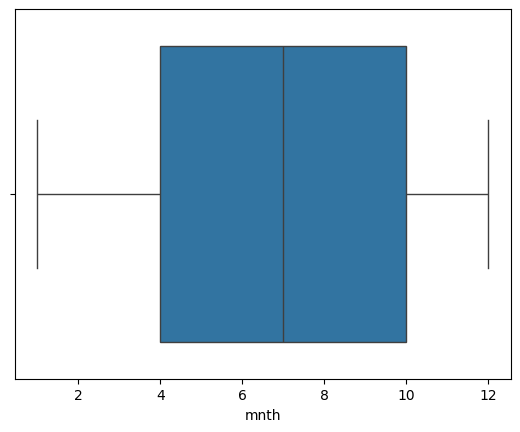

In [ ]:
sns.boxplot(x=df['mnth'])
plt.show()

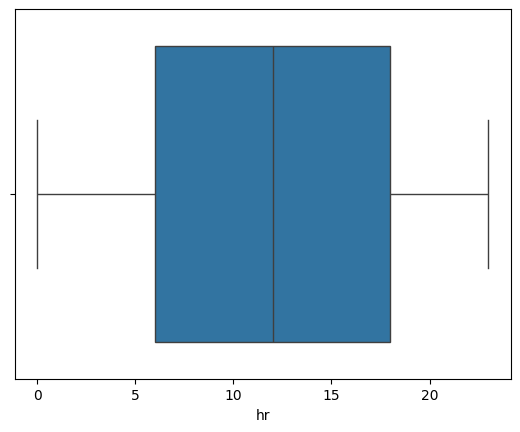

In [ ]:
sns.boxplot(x=df['hr'])
plt.show()

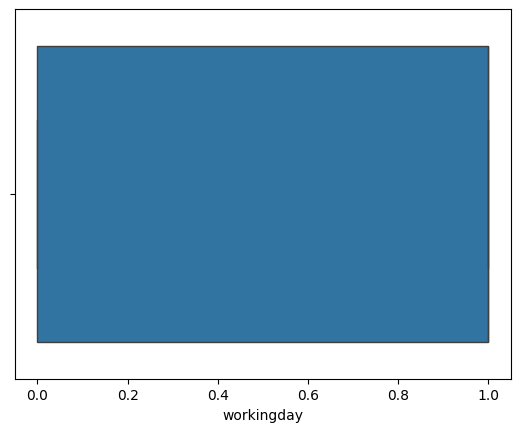

In [ ]:
sns.boxplot(x=df['workingday'])
plt.show()

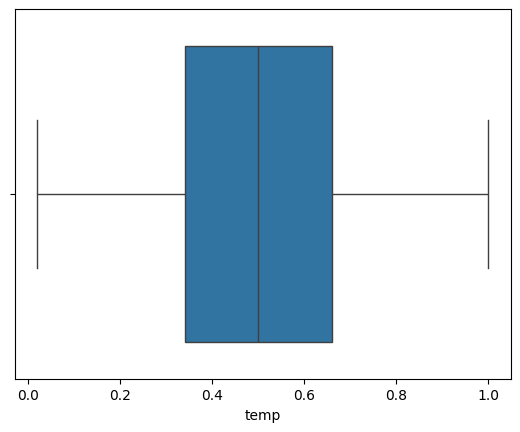

In [ ]:
sns.boxplot(x=df['temp'])
plt.show()

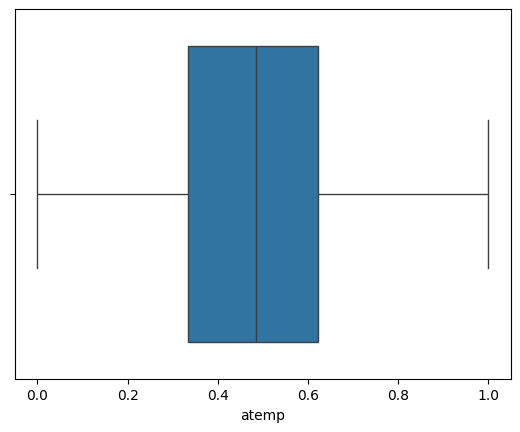

In [ ]:
sns.boxplot(x=df['atemp'])
plt.show()

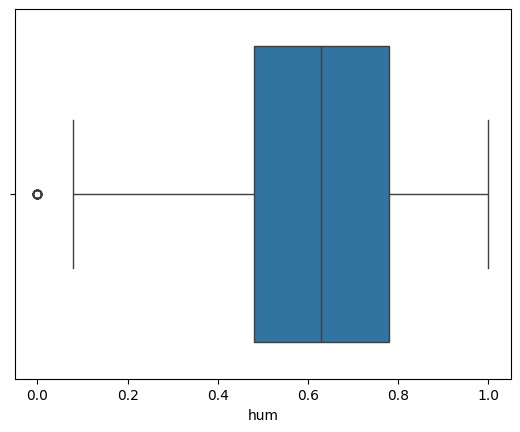

In [ ]:
sns.boxplot(x=df['hum'])
plt.show()

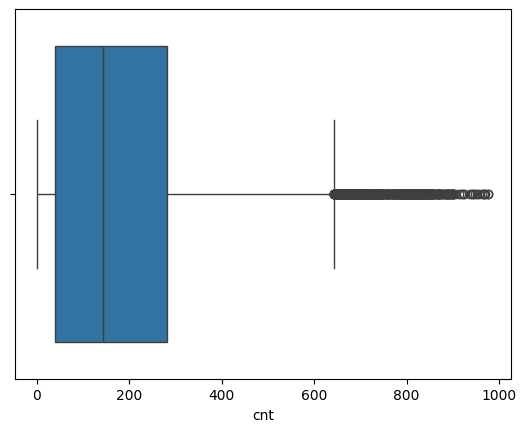

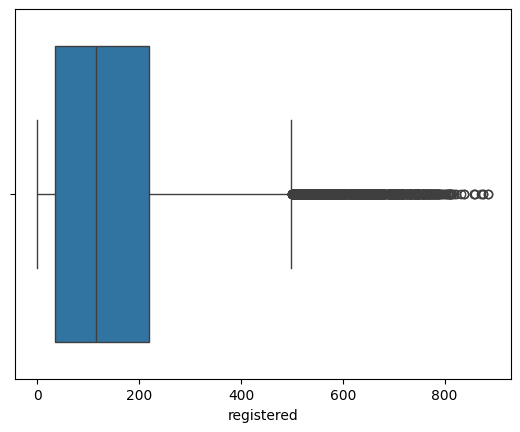

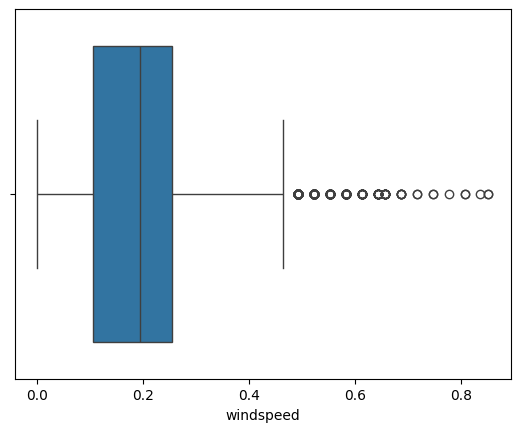

In [ ]:
sns.boxplot(x=df['cnt'])         #holiday, season, weathersit, weekday are binary or one - hot so need for them
plt.show()

sns.boxplot(x=df['registered'])
plt.show()

sns.boxplot(x=df['windspeed'])
plt.show()

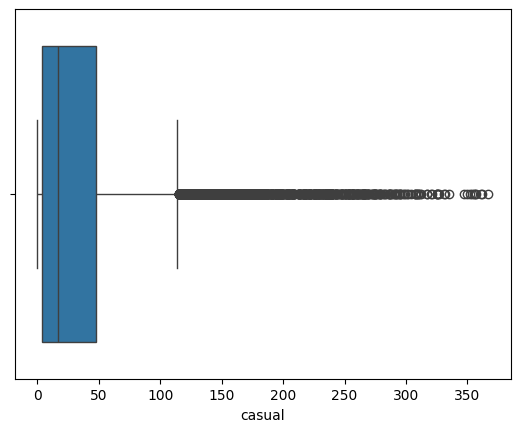

In [ ]:
sns.boxplot(x=df['casual'])
plt.show()

Time featuring processing

In [ ]:
import numpy as np

# hr and mnth are cyclical — hour 23 and hour 0 are actually close in real time,
# but as plain numbers they look far apart. Sin/cos encoding fixes this.

df['hr_sin'] = np.sin(2 * np.pi * df['hr'] / 24)
df['hr_cos'] = np.cos(2 * np.pi * df['hr'] / 24)

df['mnth_sin'] = np.sin(2 * np.pi * df['mnth'] / 12)
df['mnth_cos'] = np.cos(2 * np.pi * df['mnth'] / 12)

# drop the original hr and mnth columns since hr_sin , hr_cos and mnth_sin , mnth_cos will replace them
df.drop(columns=['hr', 'mnth'], inplace=True)

df.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,registered,cnt,season_2,...,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,casual,hr_sin,hr_cos,mnth_sin,mnth_cos
0,0,0,0,0.24,0.2879,0.81,0.0,13,16,False,...,False,False,False,False,True,3,0.000000,1.000000,0.5,0.866025
1,0,0,0,0.22,0.2727,0.80,0.0,32,40,False,...,False,False,False,False,True,8,0.258819,0.965926,0.5,0.866025
2,0,0,0,0.22,0.2727,0.80,0.0,27,32,False,...,False,False,False,False,True,5,0.500000,0.866025,0.5,0.866025
3,0,0,0,0.24,0.2879,0.75,0.0,10,13,False,...,False,False,False,False,True,3,0.707107,0.707107,0.5,0.866025
4,0,0,0,0.24,0.2879,0.75,0.0,1,1,False,...,False,False,False,False,True,0,0.866025,0.500000,0.5,0.866025


Standarization (Z- Score)

In [ ]:
from sklearn.preprocessing import StandardScaler   # no need to standarized targeted coloumn casual , registered and cnt

scaler = StandardScaler()
cols_to_scale = ['temp', 'atemp', 'hum', 'windspeed',]   # to get std = 1 , and mean = 0 for every col so that model dont consider any coloumn more important on basis of weight

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [ ]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
df.describe()

,yr,holiday,workingday,temp,atemp,hum,windspeed,registered,cnt,casual,hr_sin,hr_cos,mnth_sin,mnth_cos
count,17377.000000,17377.000000,17377.000000,1.737700e+04,1.737700e+04,1.737700e+04,1.737700e+04,17377.000000,17377.000000,17377.000000,17377.000000,1.737700e+04,1.737700e+04,1.737700e+04
mean,0.502561,0.028774,0.682742,1.177627e-16,1.766441e-16,4.514238e-16,-3.107628e-17,153.803649,189.483916,35.680267,-0.004617,-3.375046e-03,-5.505655e-03,-6.468134e-03
std,0.500008,0.167175,0.465422,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,151.357913,181.387645,49.306423,0.706782,7.074485e-01,7.054658e-01,7.087336e-01
min,0.000000,0.000000,0.000000,-2.477268e+00,-2.768669e+00,-3.251016e+00,-1.553939e+00,0.000000,1.000000,0.000000,-1.000000,-1.000000e+00,-1.000000e+00,-1.000000e+00
25%,0.000000,0.000000,0.000000,-8.153433e-01,-8.291233e-01,-7.630565e-01,-6.997594e-01,34.000000,40.000000,4.000000,-0.707107,-7.071068e-01,-8.660254e-01,-8.660254e-01
50%,1.000000,0.000000,1.000000,1.561910e-02,5.248844e-02,1.443089e-02,3.181049e-02,115.000000,142.000000,17.000000,0.000000,-1.836970e-16,-2.449294e-16,-1.836970e-16
75%,1.000000,0.000000,1.000000,8.465815e-01,8.462300e-01,7.919183e-01,5.197962e-01,220.000000,281.000000,48.000000,0.707107,7.071068e-01,5.000000e-01,8.660254e-01
max,1.000000,1.000000,1.000000,2.612377e+00,3.050550e+00,1.932233e+00,5.399653e+00,886.000000,977.000000,367.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
df.shape

(17377, 26)

In [ ]:
df.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,registered,cnt,season_2,...,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,casual,hr_sin,hr_cos,mnth_sin,mnth_cos
0,0,0,0,-1.334695,-1.093316,0.947416,-1.553939,13,16,False,...,False,False,False,False,True,3,0.000000,1.000000,0.5,0.866025
1,0,0,0,-1.438565,-1.181768,0.895583,-1.553939,32,40,False,...,False,False,False,False,True,8,0.258819,0.965926,0.5,0.866025
2,0,0,0,-1.438565,-1.181768,0.895583,-1.553939,27,32,False,...,False,False,False,False,True,5,0.500000,0.866025,0.5,0.866025
3,0,0,0,-1.334695,-1.093316,0.636421,-1.553939,10,13,False,...,False,False,False,False,True,3,0.707107,0.707107,0.5,0.866025
4,0,0,0,-1.334695,-1.093316,0.636421,-1.553939,1,1,False,...,False,False,False,False,True,0,0.866025,0.500000,0.5,0.866025


#Phase 5

Feature/Target Separation

In [ ]:
# Target
y = df['cnt']

# Features drop cnt, casual, registered (leakage)
X = df.drop(columns=['cnt', 'casual', 'registered'])

In [ ]:
X.shape

(17377, 23)

In [ ]:
y.shape

(17377,)

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80 per train , 20 per test

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(13901, 23) (3476, 23)
(13901,) (3476,)


Model Training

In [ ]:
from sklearn.linear_model import LinearRegression  #simple regression model / learn in this course

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Sample Predictions

In [ ]:
y_pred = model.predict(X_test)

# Comparison of  first 10 actual and predicted values
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
print(comparison)

   Actual   Predicted
0     333  297.064498
1     732  414.690430
2     185  126.953202
3     526  369.769702
4      13  -36.542242
5      32   -4.105922
6     706  395.446150
7      16   46.274101
8       2   65.691603
9     640  446.319171


Chceking neg presictions

In [ ]:
(y_pred < 0).sum()

np.int64(212)

# Phase 6


Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)   # Mean square Error
print("MAE:", mae)   # mean absolute error
print("RMSE:", rmse) # root mean score error
print("R2 Score:", r2)

MSE: 14993.899096944588
MAE: 90.19499052771582
RMSE: 122.44957777364766
R2 Score: 0.5116016788466125


Actual vs predicted chart

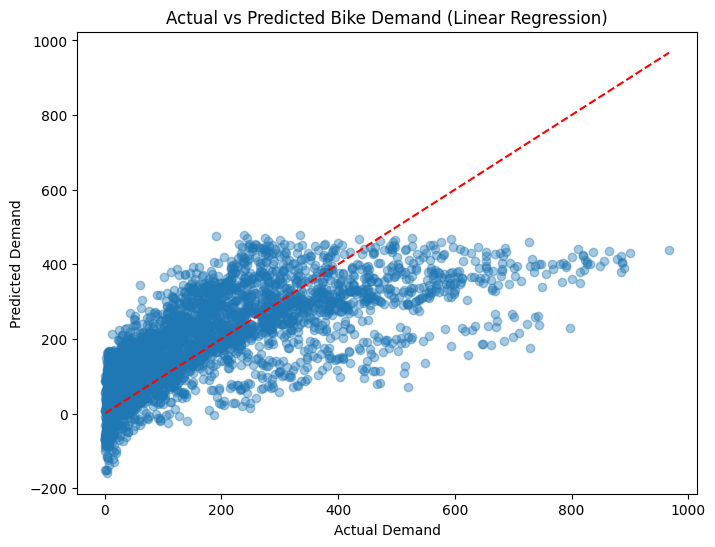

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # perfect prediction line
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Bike Demand (Linear Regression)')
plt.show()

setup to make file backend ready

In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio joblib -q

In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'scaler.pkl', 'sample_data']


In [ ]:
import joblib

# Agar Random Forest already trained hai
joblib.dump(model, 'bike_demand_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

# Verify
print(os.listdir())

['.config', 'feature_columns.pkl', 'drive', 'bike_demand_model.pkl', 'scaler.pkl', 'sample_data']


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
import pandas as pd
import joblib
from starlette.middleware.cors import CORSMiddleware

# Initialize FastAPI app
app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# Define the input data model
class BikeInput(BaseModel):
    yr: int
    mnth: int
    hr: int
    holiday: int
    weekday: int
    workingday: int
    weathersit: int
    temp: float
    atemp: float
    hum: float
    windspeed: float
    season: int

model = joblib.load('bike_demand_model.pkl')
feature_columns = joblib.load('feature_columns.pkl')
scaler = joblib.load('scaler.pkl')   # NAYA — yeh load karo

@app.post("/predict")
def predict_demand(data: BikeInput):
    hr_sin = np.sin(2 * np.pi * data.hr / 24)
    hr_cos = np.cos(2 * np.pi * data.hr / 24)
    mnth_sin = np.sin(2 * np.pi * data.mnth / 12)
    mnth_cos = np.cos(2 * np.pi * data.mnth / 12)

    # Raw values ko scale karo, bilkul training jaisa
    raw_scale_input = pd.DataFrame([[data.temp, data.atemp, data.hum, data.windspeed]],
                                     columns=['temp', 'atemp', 'hum', 'windspeed'])
    scaled_values = scaler.transform(raw_scale_input)[0]

    input_dict = {
        'yr': data.yr,
        'holiday': data.holiday,
        'workingday': data.workingday,
        'temp': scaled_values[0],
        'atemp': scaled_values[1],
        'hum': scaled_values[2],
        'windspeed': scaled_values[3],
        'hr_sin': hr_sin,
        'hr_cos': hr_cos,
        'mnth_sin': mnth_sin,
        'mnth_cos': mnth_cos,
    }

    for col in feature_columns:
        if col.startswith('season_') or col.startswith('weathersit_') or col.startswith('weekday_'):
            input_dict[col] = 0

    season_col = f'season_{data.season}'
    weather_col = f'weathersit_{data.weathersit}'
    weekday_col = f'weekday_{data.weekday}'

    if season_col in feature_columns:
        input_dict[season_col] = 1
    if weather_col in feature_columns:
        input_dict[weather_col] = 1
    if weekday_col in feature_columns:
        input_dict[weekday_col] = 1

    input_df = pd.DataFrame([input_dict])[feature_columns]

    prediction = model.predict(input_df)[0]
    prediction = max(0, round(prediction))

    return {"predicted_demand": prediction}

In [ ]:
from pyngrok import ngrok


ngrok.kill()

ngrok.set_auth_token("Your_ngrok_token")

In [ ]:
import threading
import uvicorn
import nest_asyncio

nest_asyncio.apply()

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server)
thread.start()

In [ ]:
public_url = ngrok.connect(8000)
print("Public URL:", public_url)

INFO:     Started server process [886]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Public URL: NgrokTunnel: "https://enamel-overhung-swell.ngrok-free.dev" -> "http://localhost:8000"


# Phase 4

In [ ]:
import pandas as pd

In [ ]:
df_raw = pd.read_csv("/content/drive/MyDrive/BikeRentalData.csv") #again loading raw data for EDA

In [ ]:
df_raw.drop_duplicates(inplace=True)
df_raw['casual'] = df_raw['cnt'] - df_raw['registered']

In [ ]:
df_raw.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,registered,cnt,casual
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,13,16,3
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,32,40,8
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,27,32,5
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,10,13,3
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1,0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

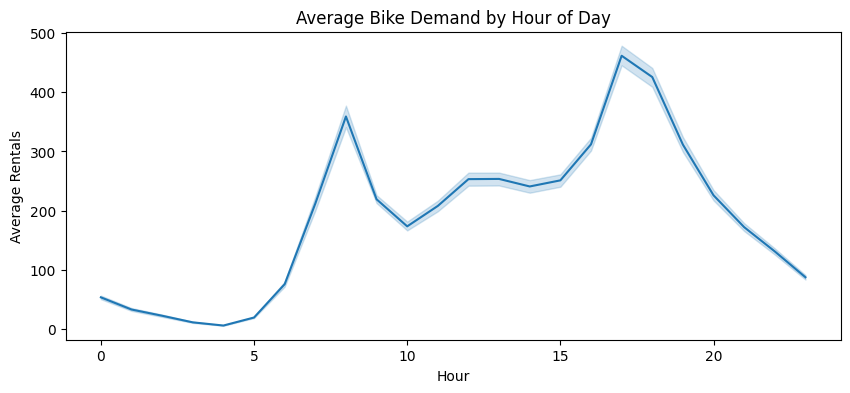

In [ ]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df_raw, x='hr', y='cnt', estimator='mean')
plt.title('Average Bike Demand by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')
plt.show()

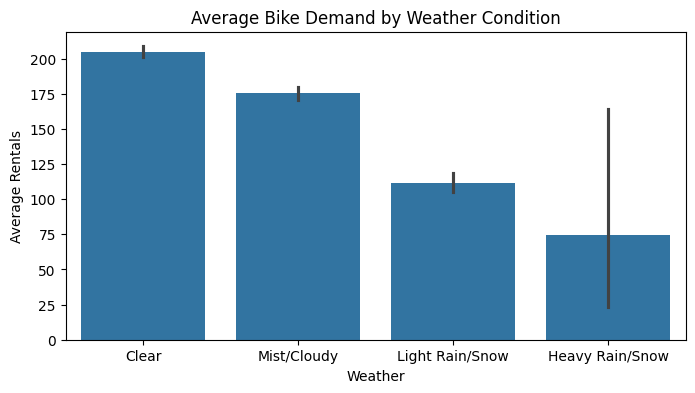

In [ ]:
weathersit_labels = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
df_raw['weathersit_label'] = df_raw['weathersit'].map(weathersit_labels)

plt.figure(figsize=(8,4))
sns.barplot(data=df_raw, x='weathersit_label', y='cnt', estimator='mean')
plt.title('Average Bike Demand by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Average Rentals')
plt.show()

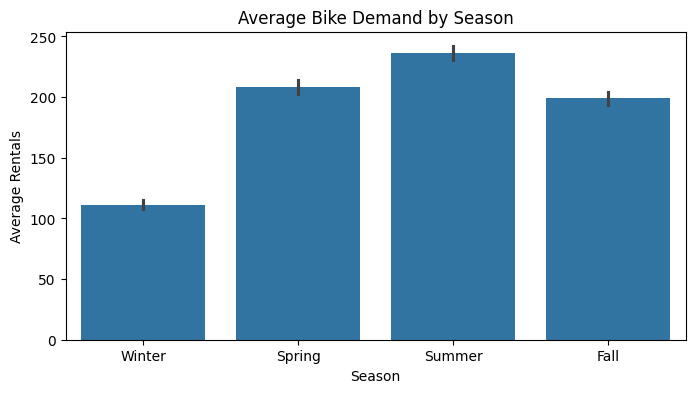

In [ ]:
season_labels = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
df_raw['season_label'] = df_raw['season'].map(season_labels)

plt.figure(figsize=(8,4))
sns.barplot(data=df_raw, x='season_label', y='cnt', estimator='mean')
plt.title('Average Bike Demand by Season')
plt.xlabel('Season')
plt.ylabel('Average Rentals')
plt.show()

Time Based Analysis

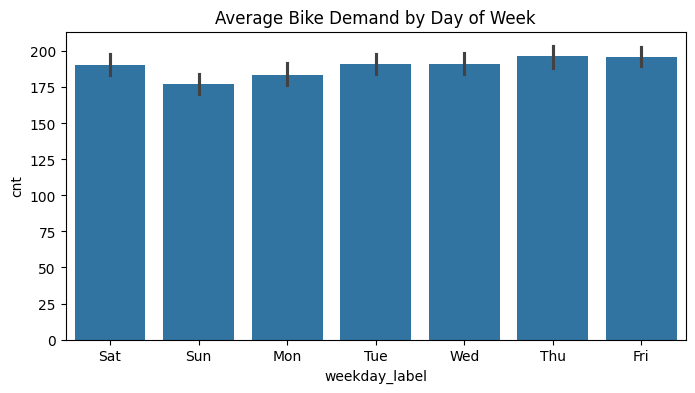

In [ ]:
weekday_labels = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}
df_raw['weekday_label'] = df_raw['weekday'].map(weekday_labels)

plt.figure(figsize=(8,4))
sns.barplot(data=df_raw, x='weekday_label', y='cnt', estimator='mean')
plt.title('Average Bike Demand by Day of Week')
plt.show()

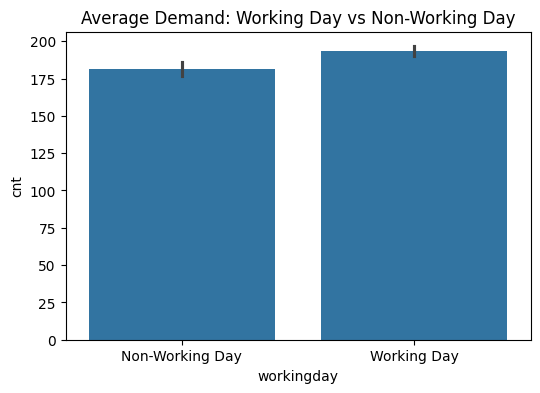

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=df_raw, x='workingday', y='cnt', estimator='mean')
plt.xticks([0,1], ['Non-Working Day', 'Working Day'])
plt.title('Average Demand: Working Day vs Non-Working Day')
plt.show()

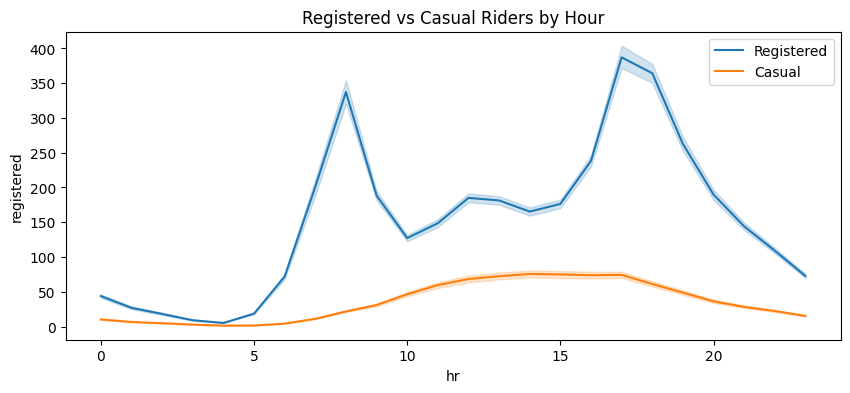

In [ ]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df_raw, x='hr', y='registered', label='Registered', estimator='mean')
sns.lineplot(data=df_raw, x='hr', y='casual', label='Casual', estimator='mean')
plt.title('Registered vs Casual Riders by Hour')
plt.legend()
plt.show()